## **Modeling & Evaluation (Random Forest) Suara Buka Tutup**

### ***1. Import & Load Data Fitur***

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

# Load dataset dengan fitur terpilih
train_df = pd.read_csv("train_features_clean.csv")
val_df   = pd.read_csv("val_features_clean.csv")

print(f"Data Train: {train_df.shape}, Data Val: {val_df.shape}")
print(f"Menggunakan {train_df.shape[1] - 1} fitur terpilih")
train_df.head()

Data Train: (145, 6), Data Val: (34, 6)
Menggunakan 5 fitur terpilih


,mel_7_std,chroma_0_mean,mel_6_std,stat_skew,mel_7_mean,label
0,0.003948,0.466429,0.008969,0.831375,0.002202,buka
1,0.084030,0.416597,0.060875,2.285544,0.028887,tutup
2,0.001691,0.376447,0.006055,1.768264,0.001273,buka
3,0.013888,0.387179,0.004689,-0.550398,0.005761,tutup
4,0.030463,0.424229,0.046075,2.255194,0.008507,tutup


### ***2. Pisahkan Fitur dan Label***

In [2]:
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']

X_val = val_df.drop(columns=['label'])
y_val = val_df['label']

### ***3. Membuat dan Latih Model Random Forest***

In [3]:
rf_model = RandomForestClassifier(
    n_estimators=200,      # jumlah pohon
    max_depth=None,        # biarkan pohon tumbuh penuh
    random_state=42,
    n_jobs=-1             
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

### ***4. Evaluasi Model di Data Validation***

In [4]:
y_pred = rf_model.predict(X_val)

acc = accuracy_score(y_val, y_pred)
print(f"Akurasi Model Random Forest: {acc*100:.2f}%\n")

print("=== Classification Report ===")
print(classification_report(y_val, y_pred))

joblib.dump(rf_model, 'model_results/rf_model_buka_tutup.pkl')

Akurasi Model Random Forest: 88.24%

=== Classification Report ===
              precision    recall  f1-score   support

        buka       0.93      0.82      0.88        17
       tutup       0.84      0.94      0.89        17

    accuracy                           0.88        34
   macro avg       0.89      0.88      0.88        34
weighted avg       0.89      0.88      0.88        34



['model_results/rf_model_buka_tutup.pkl']

### ***5. Confusion Matrix Visualization***

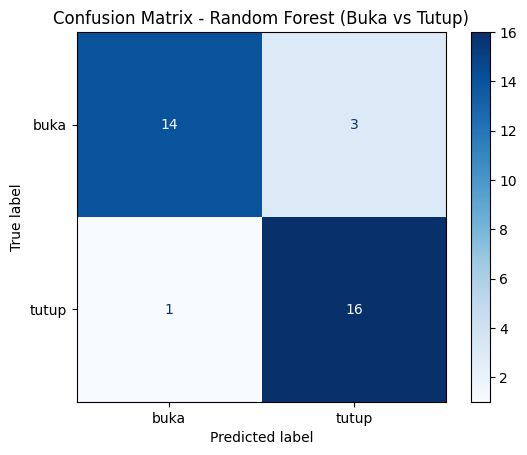

In [5]:
# Confusion Matrix
cm = confusion_matrix(y_val, y_pred, labels=rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest (Buka vs Tutup)")
plt.show()


### ***6. Feature Importance***

Menunjukkan fitur mana yang paling berpengaruh dalam keputusan model.

C:\Users\Harits Putra Junaidi\AppData\Local\Temp\ipykernel_24980\518267180.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='mako')


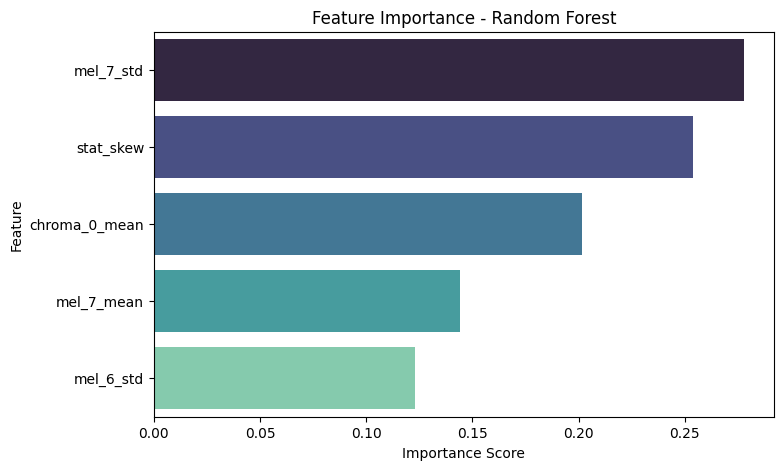

In [6]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=importances.index, palette='mako')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


In [7]:
import os
import librosa
import numpy as np
import pickle
from pathlib import Path

def extract_speaker_features(y, sr=22050):
    
    # 1. MFCC features (13 coefficients)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfccs, axis=1)
    mfcc_std = np.std(mfccs, axis=1)
    
    # 2. Pitch/Fundamental frequency
    pitches, magnitudes = librosa.core.piptrack(y=y, sr=sr)
    pitch_mean = np.mean(pitches[pitches > 0]) if np.any(pitches > 0) else 0
    
    # 3. Spectral features
    spectral_centroids = librosa.feature.spectral_centroid(y=y, sr=sr)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    zero_crossing = librosa.feature.zero_crossing_rate(y)
    
    # 4. Chroma features
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_mean = np.mean(chroma, axis=1)
    
    speaker_features = np.concatenate([
        mfcc_mean,           # 13 features
        mfcc_std,            # 13 features  
        [pitch_mean],        # 1 feature
        [np.mean(spectral_centroids)],  # 1 feature
        [np.mean(spectral_rolloff)],    # 1 feature
        [np.mean(zero_crossing)],       # 1 feature
        chroma_mean          # 12 features
    ])
    
    return speaker_features

def preprocess_audio_for_speaker_v2(y, sr, target_sr=22050):
    if sr != target_sr:
        y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)
        sr = target_sr
    
    # Durasi 2-3 detik untuk speaker profiling
    max_len = int(sr * 2.0)  # 2 detik
    if len(y) < max_len:
        y = np.pad(y, (0, max_len - len(y)), mode='constant')
    else:
        # Ambil bagian tengah jika terlalu panjang
        start = (len(y) - max_len) // 2
        y = y[start:start + max_len]
    
    # Normalisasi amplitudo
    y = y / (np.max(np.abs(y)) + 1e-6)
    
    # Noise reduction 
    y[np.abs(y) < 0.005] = 0.0
    
    return y, sr

def create_speaker_profiles_v2():    
    speaker_samples_dir = "speaker_samples"
    
    if not os.path.exists(speaker_samples_dir):
        print(f"Folder '{speaker_samples_dir}' tidak ditemukan!")
        return
    
    speaker_profiles = {}
    
    for speaker_name in os.listdir(speaker_samples_dir):
        speaker_dir = os.path.join(speaker_samples_dir, speaker_name)
        
        if not os.path.isdir(speaker_dir):
            continue
            
        print(f"\n🎤 Processing speaker: {speaker_name}")
        
        speaker_features_list = []
        
        for audio_file in os.listdir(speaker_dir):
            if audio_file.endswith('.wav'):
                audio_path = os.path.join(speaker_dir, audio_file)
                print(f"  Processing: {audio_file}")
                
                try:
                    # Load audio
                    y, sr = librosa.load(audio_path, sr=22050)
                    
                    y_processed, sr_processed = preprocess_audio_for_speaker_v2(y, sr)
                    
                    features = extract_speaker_features(y_processed, sr_processed)
                    
                    features_normalized = features / (np.linalg.norm(features) + 1e-8)
                    
                    speaker_features_list.append(features_normalized)
                    print(f"    Features extracted: {len(features)} dimensions")
                    
                except Exception as e:
                    print(f"    Error processing {audio_file}: {e}")
        
        if speaker_features_list:
            avg_features = np.mean(speaker_features_list, axis=0)
            
            avg_features_normalized = avg_features / (np.linalg.norm(avg_features) + 1e-8)
            
            feature_std = np.std(speaker_features_list, axis=0)
            variability = np.mean(feature_std)
            
            speaker_profiles[speaker_name] = avg_features_normalized
            print(f"  Profile created for {speaker_name}")
            print(f"     - Samples used: {len(speaker_features_list)}")
            print(f"     - Feature dimensions: {len(avg_features_normalized)}")
            print(f"     - Variability score: {variability:.4f}")
        else:
            print(f"  No valid audio files found for {speaker_name}")
    
    if speaker_profiles:
        with open('speaker_profiles.pkl', 'wb') as f:
            pickle.dump(speaker_profiles, f)
        
        print(f"\nSpeaker profiles saved successfully!")
        print(f"Registered speakers: {list(speaker_profiles.keys())}")
        print("File saved as: speaker_profiles.pkl")
        
        print(f"\nQuality Check - Inter-speaker similarity:")
        speakers = list(speaker_profiles.keys())
        if len(speakers) == 2:
            profile1 = speaker_profiles[speakers[0]]
            profile2 = speaker_profiles[speakers[1]]
            similarity = np.dot(profile1, profile2)
            print(f"   Similarity between {speakers[0]} and {speakers[1]}: {similarity:.4f}")
            if similarity > 0.9:
                print("   WARNING: Speakers too similar! Consider recording more diverse samples.")
            else:
                print("   Good separation between speakers.")
    else:
        print("\nNo speaker profiles created!")
if __name__ == "__main__":
    create_speaker_profiles_v2()


🎤 Processing speaker: harits
  Processing: Buka1.wav


    Features extracted: 42 dimensions
  Processing: Buka10.wav
    Features extracted: 42 dimensions
  Processing: Buka11.wav
    Features extracted: 42 dimensions
  Processing: Buka12.wav
    Features extracted: 42 dimensions
  Processing: Buka13.wav
    Features extracted: 42 dimensions
  Processing: Buka14.wav
    Features extracted: 42 dimensions
  Processing: Buka15.wav
    Features extracted: 42 dimensions
  Processing: Buka16.wav
    Features extracted: 42 dimensions
  Processing: Buka17.wav
    Features extracted: 42 dimensions
  Processing: Buka18.wav


    Features extracted: 42 dimensions
  Processing: Buka19.wav
    Features extracted: 42 dimensions
  Processing: Buka2.wav
    Features extracted: 42 dimensions
  Processing: Buka20.wav
    Features extracted: 42 dimensions
  Processing: Buka21.wav
    Features extracted: 42 dimensions
  Processing: Buka22.wav
    Features extracted: 42 dimensions
  Processing: Buka23.wav
    Features extracted: 42 dimensions
  Processing: Buka24.wav
    Features extracted: 42 dimensions
  Processing: Buka25.wav


    Features extracted: 42 dimensions
  Processing: Buka26.wav
    Features extracted: 42 dimensions
  Processing: Buka27.wav
    Features extracted: 42 dimensions
  Processing: Buka28.wav
    Features extracted: 42 dimensions
  Processing: Buka29.wav
    Features extracted: 42 dimensions
  Processing: Buka3.wav
    Features extracted: 42 dimensions
  Processing: Buka30.wav
    Features extracted: 42 dimensions
  Processing: Buka31.wav


    Features extracted: 42 dimensions
  Processing: Buka32.wav
    Features extracted: 42 dimensions
  Processing: Buka33.wav
    Features extracted: 42 dimensions
  Processing: Buka34.wav
    Features extracted: 42 dimensions
  Processing: Buka35.wav
    Features extracted: 42 dimensions
  Processing: Buka36.wav
    Features extracted: 42 dimensions
  Processing: Buka37.wav
    Features extracted: 42 dimensions
  Processing: Buka39.wav


...

    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.03​(3).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.03​(4).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.03​(5).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.03​(6).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.03​(7).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.03​(8).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.03​(9).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.03​.wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.04​(10).wav


    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.04​(11).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.04​(12).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.04​(13).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.04​(2).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.04​(3).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.04​(4).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.04​(5).wav


    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.04​(6).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.04​(7).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.04​(8).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.04​(9).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.04​.wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.05​(10).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.05​(11).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.05​(12).wav


    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.05​(13).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.05​(2).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.05​(3).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.05​(4).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.05​(5).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.05​(6).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.05​(7).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.05​(8).wav


    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.05​(9).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.05​.wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.06​(2).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.06​(3).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.06​(4).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.06​(5).wav
    Features extracted: 42 dimensions
  Processing: 6 Nov, 19.06​.wav
    Features extracted: 42 dimensions
  Profile created for lutfi
     - Samples used: 102
     - Feature dimensions: 42
     - Variability score: 0.0035

Speaker profiles saved successfully!
Registered speakers: ['harits', 'lutfi']
File saved as: speaker_profiles.pkl

Quality Check - Inter-speaker similarity:
   Similarity between harits and lutfi: 0.9964


### ***7. Prediksi Suara Buka Tutup***

In [8]:
import os
import librosa
import numpy as np
import pandas as pd
from scipy import stats
import IPython.display as ipd

In [9]:
### ***7. Prediksi Suara Buka Tutup (Optimized)***
import os
import librosa
import numpy as np
import pandas as pd
from scipy import stats
import IPython.display as ipd

def extract_only_selected_features(y, sr=22050):

    feats = {}
    
    feats['stat_skew'] = stats.skew(y)
    
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    feats['chroma_0_mean'] = np.mean(chroma[0])
    
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=10)
    feats['mel_6_std'] = np.std(mel_spec[6])
    feats['mel_7_mean'] = np.mean(mel_spec[7])
    feats['mel_7_std'] = np.std(mel_spec[7])
    
    return feats

def find_audio_file():
    buka_folder = "dataset48k/train/buka/"
    if os.path.exists(buka_folder):
        audio_files = [f for f in os.listdir(buka_folder) if f.endswith('.wav')]
        if audio_files:
            return os.path.join(buka_folder, audio_files[58])
    return None

# Main prediction
test_file = find_audio_file()
rf_model = joblib.load('model_results/rf_model_buka_tutup.pkl')

if test_file is None:
    print("Tidak ada file audio yang ditemukan!")
else:
    print(f"Menggunakan file: {test_file}")
    
    # Tampilkan audio
    ipd.display(ipd.Audio(test_file))
    
    # Preprocess (sama seperti saat training)
    y, sr = librosa.load(test_file, sr=22050)
    
    # Durasi 1 detik
    max_len = int(sr * 1.0)
    if len(y) < max_len:
        y = np.pad(y, (0, max_len - len(y)), mode='constant')
    else:
        y = y[:max_len]
    
    # Normalisasi
    y = y / np.max(np.abs(y) + 1e-6)
    
    # Noise reduction
    y[np.abs(y) < 0.005] = 0.0
    
    selected_features = extract_only_selected_features(y, sr)
    
    print(f"\n🔍 FITUR YANG DIEKSTRAKSI:")
    print(f"{'='*40}")
    for feat_name, feat_value in selected_features.items():
        print(f"{feat_name:<15}: {feat_value:.6f}")
    
    feature_order = ['mel_7_std', 'chroma_0_mean', 'mel_6_std', 'stat_skew', 'mel_7_mean']
    X_new = pd.DataFrame([selected_features])[feature_order]
    
    print(f"\nNPUT SHAPE: {X_new.shape}")
    print(f"FEATURE ORDER: {list(X_new.columns)}")
    
    # Prediksi
    pred_label = rf_model.predict(X_new)[0]
    pred_proba = rf_model.predict_proba(X_new)[0]
    
    print(f"\nHASIL PREDIKSI")
    print(f"{'='*30}")
    print(f"Prediksi: **{pred_label.upper()}**")
    print(f"Confidence: {max(pred_proba)*100:.1f}%")
    
    classes = rf_model.classes_
    for i, cls in enumerate(classes):
        print(f"P({cls}): {pred_proba[i]*100:.1f}%")

Menggunakan file: dataset48k/train/buka/Buka16.wav



🔍 FITUR YANG DIEKSTRAKSI:
stat_skew      : 1.704719
chroma_0_mean  : 0.766378
mel_6_std      : 0.001496
mel_7_mean     : 0.000614
mel_7_std      : 0.001074

NPUT SHAPE: (1, 5)
FEATURE ORDER: ['mel_7_std', 'chroma_0_mean', 'mel_6_std', 'stat_skew', 'mel_7_mean']

HASIL PREDIKSI
Prediksi: **BUKA**
Confidence: 100.0%
P(buka): 100.0%
P(tutup): 0.0%
